In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from pyod.utils.data import generate_data

n_train = 200
n_test = 50

n_train = 200 -> Number of training samples

n_test = 50 -> Number of testing samples

In [3]:
X_train, X_test, y_train, y_test = generate_data(n_train=n_train, n_test=n_test, n_features=2, contamination=0.05)

generate_data() a fuction that generates a dataset with:

2 features (simulating two IIoT sensor readings)

5% contamination (5% of the dataset will be anomalies)

X_train -> Training feature set

X_test -> Test feature set

y_train -> Labels for training (1 = anomaly, 0 = normal)

y_test -> Labels for testing (used for validation)

In [5]:
clf = IForest()
clf.fit(X_train)

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=None,
    verbose=0)

IForest() initializes the Isolation Forest anomaly detection model

clf.fit(X_train) trains the model on the training dataset


In [8]:
y_test_pred = clf.predict(X_test)
print(y_test_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1]


clf.predict(X_test) predicts whether each test sample is anomalous (1) or normal (0)

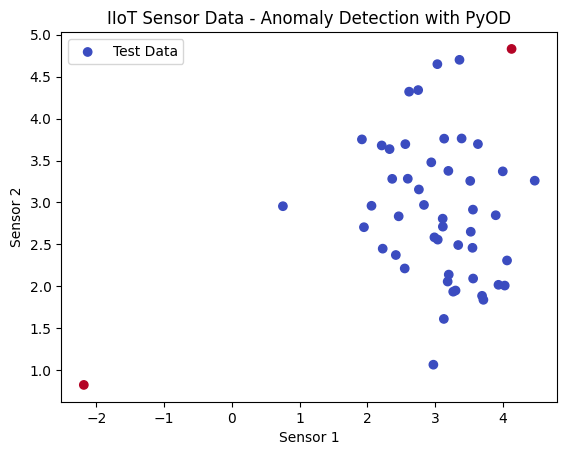

In [9]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_pred, cmap="coolwarm", label="Test Data")
plt.title("IIoT Sensor Data - Anomaly Detection with PyOD")
plt.xlabel("Sensor 1")
plt.ylabel("Sensor 2")
plt.legend()
plt.show()

It worked succesfully, two anomalies were found, sensor 1 and sensor 2 just a placeholders. More likely in a real-world situation two features will be used instead depending on where are we trying to find anomaly. For example 1. Temperature of a machine 2. Pressure in a pipeline